## 1. Imports

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Data

In [2]:
n = 5000

age = np.random.randint(18, 70, n)
annual_income = np.random.gamma(shape=5, scale=12000, size=n).clip(10000, 300000)
num_bank_accounts = np.random.randint(1, 10, n)
num_credit_cards = np.random.randint(0, 12, n)
interest_rate = np.random.uniform(2, 34, n)
num_loans = np.random.randint(0, 9, n)
delay_from_due_date = np.random.randint(0, 60, n)
num_delayed_payments = np.random.randint(0, 25, n)
credit_utilization = np.random.uniform(10, 99, n)
credit_history_age_months = np.random.randint(6, 360, n)
outstanding_debt = np.random.gamma(shape=2, scale=1500, size=n)
monthly_balance = np.random.normal(400, 250, n).clip(-500, 3000)
num_credit_inquiries = np.random.randint(0, 15, n)
payment_of_min_amount = np.random.choice(["Yes", "No", "NM"], n, p=[0.5, 0.35, 0.15])
occupation = np.random.choice(
    ["Engineer", "Doctor", "Teacher", "Lawyer", "Accountant",
     "Entrepreneur", "Scientist", "Manager", "Other"], n
)

# --- Derive a latent "risk score" from the features (higher = worse) ---
risk_score = (
    0.9 * (num_delayed_payments / 25)
    + 0.8 * (delay_from_due_date / 60)
    + 0.7 * (credit_utilization / 99)
    + 0.6 * (outstanding_debt / outstanding_debt.max())
    + 0.5 * (num_credit_inquiries / 15)
    + 0.4 * (interest_rate / 34)
    - 0.6 * (annual_income / annual_income.max())
    - 0.5 * (credit_history_age_months / 360)
    - 0.3 * (monthly_balance / monthly_balance.max())
    + np.where(payment_of_min_amount == "No", 0.4, 0)
    + np.random.normal(0, 0.25, n)  # noise
)

# Bucket into 3 classes using quantiles -> roughly balanced but realistic
q1, q2 = np.quantile(risk_score, [0.33, 0.70])
credit_score = np.where(risk_score <= q1, "Good",
                 np.where(risk_score <= q2, "Standard", "Poor"))

df = pd.DataFrame({
    "Age": age,
    "Annual_Income": annual_income.round(2),
    "Num_Bank_Accounts": num_bank_accounts,
    "Num_Credit_Card": num_credit_cards,
    "Interest_Rate": interest_rate.round(2),
    "Num_of_Loan": num_loans,
    "Delay_from_due_date": delay_from_due_date,
    "Num_of_Delayed_Payment": num_delayed_payments,
    "Credit_Utilization_Ratio": credit_utilization.round(2),
    "Credit_History_Age_Months": credit_history_age_months,
    "Outstanding_Debt": outstanding_debt.round(2),
    "Monthly_Balance": monthly_balance.round(2),
    "Num_Credit_Inquiries": num_credit_inquiries,
    "Payment_of_Min_Amount": payment_of_min_amount,
    "Occupation": occupation,
    "Credit_Score": credit_score
})

print(df.shape)
df.head()


(5000, 16)


,Age,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Credit_Utilization_Ratio,Credit_History_Age_Months,Outstanding_Debt,Monthly_Balance,Num_Credit_Inquiries,Payment_of_Min_Amount,Occupation,Credit_Score
0,56,53202.37,6,4,31.44,5,27,8,56.47,14,4106.04,456.96,1,NM,Teacher,Good
1,69,69911.59,8,6,17.66,5,5,18,78.88,206,5466.43,899.77,12,No,Accountant,Poor
2,46,36448.23,1,5,29.79,3,41,19,80.35,248,3839.52,-160.06,11,NM,Scientist,Poor
3,32,52425.60,2,11,29.42,6,47,2,75.39,74,4827.43,282.51,3,Yes,Other,Standard
4,60,23840.29,2,4,28.10,8,53,22,57.11,244,1349.73,302.49,3,No,Accountant,Poor


## 3. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        5000 non-null   int32  
 1   Annual_Income              5000 non-null   float64
 2   Num_Bank_Accounts          5000 non-null   int32  
 3   Num_Credit_Card            5000 non-null   int32  
 4   Interest_Rate              5000 non-null   float64
 5   Num_of_Loan                5000 non-null   int32  
 6   Delay_from_due_date        5000 non-null   int32  
 7   Num_of_Delayed_Payment     5000 non-null   int32  
 8   Credit_Utilization_Ratio   5000 non-null   float64
 9   Credit_History_Age_Months  5000 non-null   int32  
 10  Outstanding_Debt           5000 non-null   float64
 11  Monthly_Balance            5000 non-null   float64
 12  Num_Credit_Inquiries       5000 non-null   int32  
 13  Payment_of_Min_Amount      5000 non-null   objec

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,43.584600,14.919094,18.00,31.0000,43.000,56.0000,69.00
Annual_Income,5000.0,59684.332598,26659.916984,10000.00,40137.5800,55610.030,75256.8050,178783.00
Num_Bank_Accounts,5000.0,4.961600,2.586477,1.00,3.0000,5.000,7.0000,9.00
Num_Credit_Card,5000.0,5.517400,3.439893,0.00,3.0000,6.000,8.0000,11.00
Interest_Rate,5000.0,18.077194,9.179724,2.00,10.1400,18.115,25.8700,33.99
Num_of_Loan,5000.0,4.072800,2.577136,0.00,2.0000,4.000,6.0000,8.00
Delay_from_due_date,5000.0,29.795800,17.569412,0.00,15.0000,30.000,45.0000,59.00
Num_of_Delayed_Payment,5000.0,11.988200,7.254667,0.00,6.0000,12.000,18.0000,24.00
Credit_Utilization_Ratio,5000.0,54.453482,25.855202,10.00,32.3100,54.115,77.2425,98.99
Credit_History_Age_Months,5000.0,181.273000,101.211175,6.00,94.0000,180.000,268.0000,359.00


In [5]:
print(df['Credit_Score'].value_counts())
print()
print(df.isnull().sum().sum(), "missing values")


Standard    1850
Good        1650
Poor        1500
Name: Credit_Score, dtype: int64

0 missing values


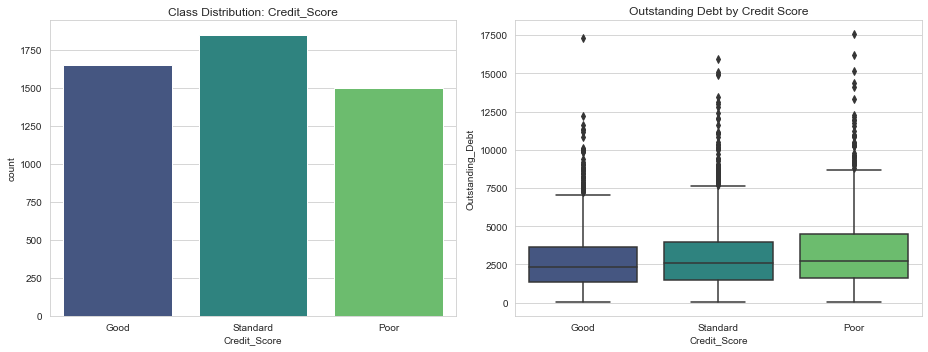

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x="Credit_Score", order=["Good", "Standard", "Poor"],
              palette="viridis", ax=ax[0])
ax[0].set_title("Class Distribution: Credit_Score")

sns.boxplot(data=df, x="Credit_Score", y="Outstanding_Debt",
            order=["Good", "Standard", "Poor"], palette="viridis", ax=ax[1])
ax[1].set_title("Outstanding Debt by Credit Score")

plt.tight_layout()
plt.show()

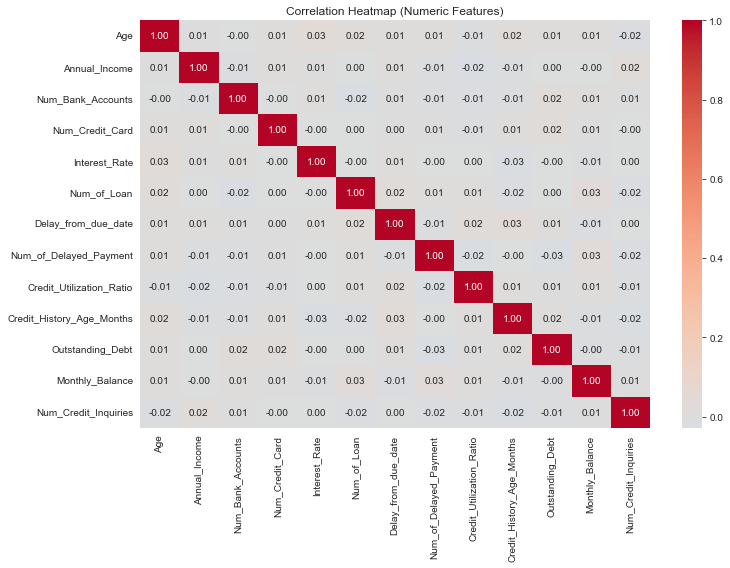

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


## 4. Preprocessing


In [8]:
target_col = "Credit_Score"
X = df.drop(columns=[target_col])
y = df[target_col]

# One-hot encode categoricals
X = pd.get_dummies(X, columns=["Payment_of_Min_Amount", "Occupation"], drop_first=True)

# Encode target: Good=0, Standard=1, Poor=2 (order chosen explicitly for readability)
label_order = ["Good", "Standard", "Poor"]
le = LabelEncoder()
le.fit(label_order)
y_enc = le.transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

# Scale only the numeric (non-dummy) columns
numeric_features = df.select_dtypes(include=[np.number]).drop(columns=[], errors="ignore").columns
numeric_features = [c for c in numeric_features if c in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (4000, 23)  Test shape: (1000, 23)


## 5. Baseline Models

In [9]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    results[name] = {"model": model, "accuracy": acc, "preds": preds}
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_te, preds, target_names=label_order))
    return model

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
evaluate_model("Logistic Regression", log_reg, X_train_scaled, y_train, X_test_scaled, y_test)


--- Logistic Regression ---
Accuracy: 0.7470

              precision    recall  f1-score   support

        Good       0.81      0.79      0.80       330
    Standard       0.80      0.78      0.79       300
        Poor       0.66      0.68      0.67       370

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.75      0.75      0.75      1000



LogisticRegression(max_iter=1000, random_state=42)

In [10]:
dt = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
evaluate_model("Decision Tree", dt, X_train_scaled, y_train, X_test_scaled, y_test)


--- Decision Tree ---
Accuracy: 0.5920

              precision    recall  f1-score   support

        Good       0.70      0.67      0.68       330
    Standard       0.62      0.59      0.61       300
        Poor       0.49      0.52      0.50       370

    accuracy                           0.59      1000
   macro avg       0.60      0.59      0.60      1000
weighted avg       0.60      0.59      0.59      1000



DecisionTreeClassifier(max_depth=8, random_state=42)

## 6. Stronger Models: Random Forest & Gradient Boosting

In [11]:
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
evaluate_model("Random Forest", rf, X_train_scaled, y_train, X_test_scaled, y_test)


--- Random Forest ---
Accuracy: 0.7260

              precision    recall  f1-score   support

        Good       0.82      0.76      0.79       330
    Standard       0.79      0.70      0.74       300
        Poor       0.62      0.72      0.67       370

    accuracy                           0.73      1000
   macro avg       0.74      0.73      0.73      1000
weighted avg       0.74      0.73      0.73      1000



RandomForestClassifier(max_depth=12, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [12]:
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE)
evaluate_model("Gradient Boosting", gb, X_train_scaled, y_train, X_test_scaled, y_test)


--- Gradient Boosting ---
Accuracy: 0.7350

              precision    recall  f1-score   support

        Good       0.82      0.79      0.80       330
    Standard       0.77      0.74      0.76       300
        Poor       0.64      0.68      0.66       370

    accuracy                           0.73      1000
   macro avg       0.74      0.74      0.74      1000
weighted avg       0.74      0.73      0.74      1000



GradientBoostingClassifier(n_estimators=200, random_state=42)

## 7. Hyperparameter Tuning with GridSearchCV


In [15]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1-macro:", grid_search.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Best CV F1-macro: 0.7031750064630223


In [16]:
best_rf = grid_search.best_estimator_
evaluate_model("Tuned Random Forest", best_rf, X_train_scaled, y_train, X_test_scaled, y_test)


--- Tuned Random Forest ---
Accuracy: 0.7120

              precision    recall  f1-score   support

        Good       0.82      0.76      0.79       330
    Standard       0.77      0.66      0.71       300
        Poor       0.60      0.71      0.65       370

    accuracy                           0.71      1000
   macro avg       0.73      0.71      0.72      1000
weighted avg       0.72      0.71      0.71      1000



RandomForestClassifier(max_depth=8, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=400, n_jobs=-1, random_state=42)

## 8. Model Comparison

In [17]:
comparison = pd.DataFrame({
    name: {"Accuracy": res["accuracy"]} for name, res in results.items()
}).T.sort_values("Accuracy", ascending=False)

comparison


,Accuracy
Logistic Regression,0.747
Gradient Boosting,0.735
Random Forest,0.726
Tuned Random Forest,0.712
Decision Tree,0.592


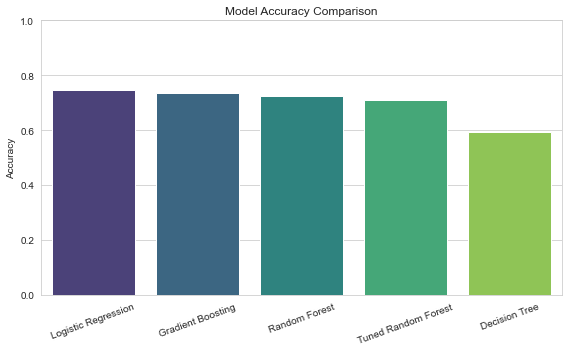

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(x=comparison.index, y=comparison["Accuracy"], palette="viridis")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 9. Confusion Matrix — Best Model

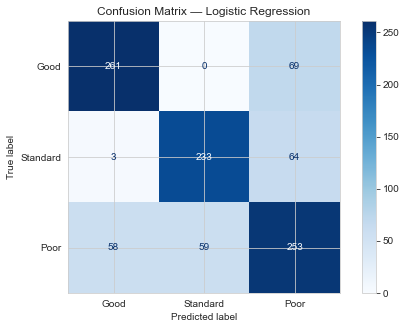

In [19]:
best_name = comparison.index[0]
best_preds = results[best_name]["preds"]

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()


## 10. ROC-AUC (One-vs-Rest, Multiclass)

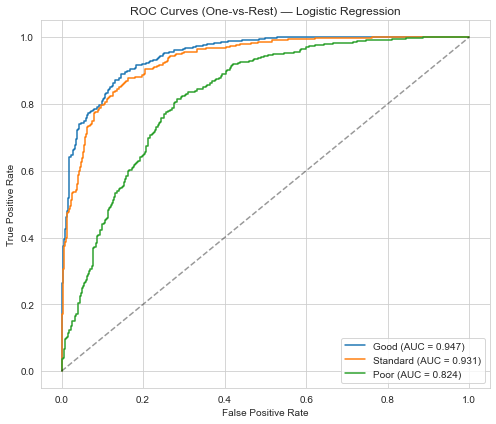

In [20]:
best_model = results[best_name]["model"]
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = best_model.predict_proba(X_test_scaled)

plt.figure(figsize=(7, 6))
for i, cls in enumerate(label_order):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves (One-vs-Rest) — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Feature Importance

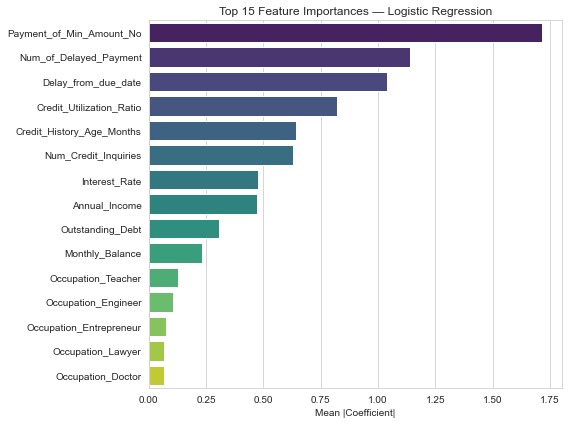

In [21]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns)
    imp_label = "Importance"
elif hasattr(best_model, "coef_"):
    # For linear models: average |coefficient| across classes as an importance proxy
    importances = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=X_train_scaled.columns)
    imp_label = "Mean |Coefficient|"
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Top 15 Feature Importances — {best_name}")
    plt.xlabel(imp_label)
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not expose feature importances or coefficients.")


## 12. Predict on a New Customer


In [22]:
new_customer = pd.DataFrame([{
    "Age": 35,
    "Annual_Income": 62000,
    "Num_Bank_Accounts": 3,
    "Num_Credit_Card": 2,
    "Interest_Rate": 14.5,
    "Num_of_Loan": 1,
    "Delay_from_due_date": 5,
    "Num_of_Delayed_Payment": 2,
    "Credit_Utilization_Ratio": 32.0,
    "Credit_History_Age_Months": 96,
    "Outstanding_Debt": 1800,
    "Monthly_Balance": 450,
    "Num_Credit_Inquiries": 2,
    "Payment_of_Min_Amount_No": 0,
    "Payment_of_Min_Amount_Yes": 1,
}])

# Align columns with training data (fill any missing dummy columns with 0)
new_customer = new_customer.reindex(columns=X_train.columns, fill_value=0)
new_customer[numeric_features] = scaler.transform(new_customer[numeric_features])

pred_class = best_model.predict(new_customer)[0]
pred_proba = best_model.predict_proba(new_customer)[0]

print("Predicted Credit Score:", label_order[pred_class])
print("Class probabilities:", dict(zip(label_order, pred_proba.round(3))))


Predicted Credit Score: Good
Class probabilities: {'Good': 0.998, 'Standard': 0.0, 'Poor': 0.002}
